In [350]:
import scipy as sp
from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones

In [147]:
x = linspace(0, 10)

In [148]:
jv1 = jv(0, x)
yv1 = yv(0, x)
hv2 = hankel2(0, x)

# Verifying scipy hankel functions

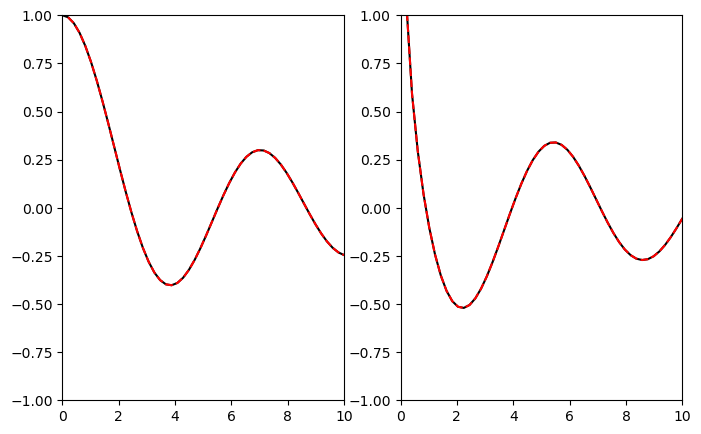

In [149]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 5))
ax1.plot(x, jv1, color="black")
ax1.plot(x, hv2.real, color="red", linestyle="dashed")
ax1.set_ylim(-1, 1);
ax1.set_xlim(0, 10);

ax2.plot(x, -yv1, color="black")
ax2.plot(x, hv2.imag, color="red", linestyle="dashed")
ax2.set_ylim(-1, 1);
ax2.set_xlim(0, 10);

In [393]:
def hl2(n, x):
    return spherical_jn(n, x) - 1j * spherical_yn(n, x)

def hl2prime(n, x):
    hn = spherical_hankel2(n, x)
    hn1 = spherical_hankel2(n+1, x)
    return n/x * hn - hn1

In [428]:
M = 1000
x = np.linspace(0.01, 1, M) # Free space kR

N = 1000
min_vals = zeros(N)
imepsv = linspace(2, 3, N)
for (i, imeps) in enumerate(imepsv):
    epsilon = -2.6 + imeps*1j
    l = 1 # order of mode (bessel/hankel function)
    y = x * sqrt(epsilon) # epsilonkR in the sphere
    
    xhl2_prime = hl2(l, x) + x * hl2prime(l, x)
    yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
    
    lhs = epsilon * spherical_jn(l, y) * xhl2_prime 
    rhs =  yjl_prime * hl2(l, x)
    min_vals[i] = min(np.abs(rhs-lhs))

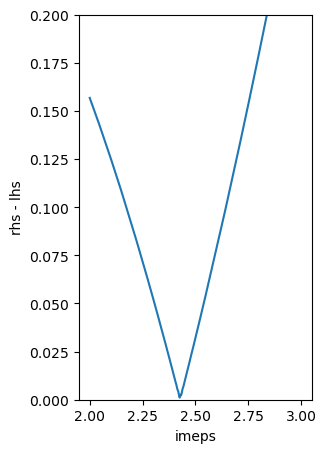

In [429]:
plt.figure(figsize=(3, 5))
plt.plot(imepsv, min_vals)
plt.ylim(0, 0.2)
plt.ylabel("rhs - lhs")
plt.xlabel("imeps");

# Find the radius corresponding to the above

In [430]:
M = 1000
x = np.linspace(0.01, 1, M) # Free space kR

epsilon = -2.6 + imepsv[np.argmin(min_vals)]*1j
l = 1 # order of mode (bessel/hankel function)
y = x * sqrt(epsilon) # epsilonkR in the sphere

xhl2_prime = hl2(l, x) + x * hl2prime(l, x)
yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)

lhs = epsilon * spherical_jn(l, y) * xhl2_prime 
rhs =  yjl_prime * hl2(l, x)

In [431]:
x[np.argmin(abs(lhs-rhs))]

0.8870270270270271

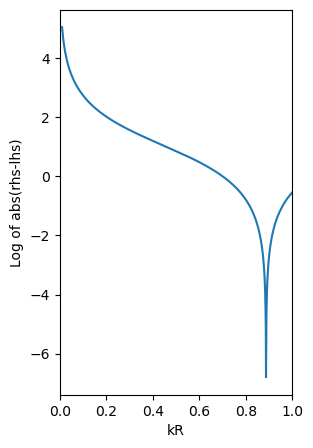

In [434]:
plt.figure(figsize=(3, 5))
plt.plot(x, np.log(abs(lhs-rhs)))
plt.xlim(0, 1)
plt.xlabel("kR")
plt.ylabel("Log of abs(rhs-lhs)");

# Recreating figure 2(a)

In [501]:
M = 150
N = 150
real_eps_v = linspace(-3, -1.5, N, endpoint=True)
im_eps_v = linspace(0.01, 3, M, endpoint=True)

In [502]:
epsilon_arr = real_eps_v.reshape((N, 1)).repeat(M,1) + 1j * im_eps_v.reshape((1, M)).repeat(N, 0);
xs = linspace(0.01, 1, 1000, endpoint=True)
sqrt_epsilon_arr = sqrt(epsilon_arr)
l = 1 # order of mode (bessel/hankel function)

In [503]:
best_real_epses = zeros(len(xs))
best_imag_epses = zeros(len(xs))

for (i, kr) in enumerate(xs):
    x = kr * ones((N, M))
    y = x * sqrt_epsilon_arr # epsilonkR in the sphere
    
    xhl2_prime = hl2(l, x) + x * hl2prime(l, x)
    yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
    
    lhs = epsilon_arr * spherical_jn(l, y) * xhl2_prime 
    rhs =  yjl_prime * hl2(l, x)
    idx = np.argmin(abs(rhs - lhs))
    row, col = np.unravel_index(idx, epsilon_arr.shape)
    best_real_epses[i] = real_eps_v[row]
    best_imag_epses[i] = im_eps_v[col]


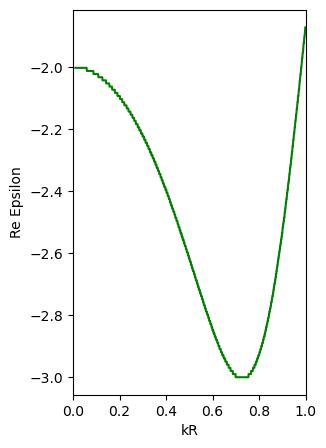

In [513]:
plt.figure(figsize=(3, 5))
plt.plot(xs, best_real_epses, color="green")
plt.xlabel("kR")
plt.ylabel("Re Epsilon")
plt.xlim(0, 1);

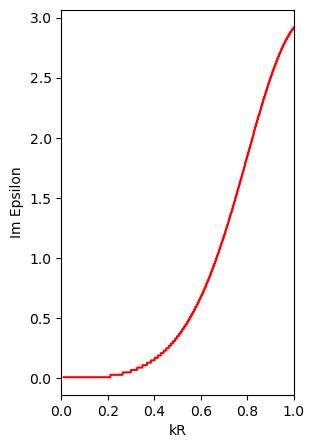

In [512]:
plt.figure(figsize=(3, 5))
plt.plot(xs, best_imag_epses, color="red")
plt.xlabel("kR")
plt.ylabel("Im Epsilon")
plt.xlim(0, 1);